# Feature Engineering for Line vs Arc Classification

**Goal**: Create discriminative features that distinguish between line and arc trajectories

**Key Differences**:
- **Lines**: Constant direction, zero/low curvature, straight path
- **Arcs**: Changing direction, consistent curvature, circular path, constant radius


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis, skew
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)


## 1. Load and Explore Data


In [2]:
# Load data
df = pd.read_csv('../../data/combined_data.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f"Total data points: {len(df):,}")
print(f"Unique shapes: {df['shape_id'].nunique():,}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label'].value_counts().sort_index())
print(f"\nShape types:")
print(df['shape'].value_counts())
df.head()


Total data points: 1,209,904
Unique shapes: 10,000

Columns: ['x', 'y', 'label', 'shape', 'shape_id']

Label distribution:
label
0    420462
1    741132
2     48310
Name: count, dtype: int64

Shape types:
shape
capsule                  174104
parallelogram_simple     137222
square_simple            136691
rectangle_simple         131902
semicircle               109083
triangle_simple           98168
circle                    97562
rectangle_rounded         84171
square_rounded            82089
parallelogram_rounded     81997
triangle_rounded          76915
Name: count, dtype: int64


,x,y,label,shape,shape_id
0,102.172567,87.946284,1,capsule,1
1,101.534607,86.660456,1,capsule,1
2,100.896646,85.374628,1,capsule,1
3,100.258686,84.088800,1,capsule,1
4,99.620726,82.802971,1,capsule,1


In [5]:
# What do the labels mean?
label_shape_mapping = df.groupby('label')['shape'].apply(lambda x: x.unique()).to_dict()
print("Label to Shape mapping:")
for label, shapes in label_shape_mapping.items():
    print(f"  Label {label}: {shapes}")


Label to Shape mapping:
  Label 0: ['capsule' 'triangle_rounded' 'circle' 'semicircle' 'square_rounded'
 'parallelogram_rounded' 'rectangle_rounded']
  Label 1: ['capsule' 'triangle_rounded' 'parallelogram_simple' 'semicircle'
 'square_rounded' 'square_simple' 'parallelogram_rounded'
 'rectangle_simple' 'triangle_simple' 'rectangle_rounded']
  Label 2: ['capsule' 'triangle_rounded' 'circle' 'parallelogram_simple' 'semicircle'
 'square_rounded' 'square_simple' 'parallelogram_rounded'
 'rectangle_simple' 'triangle_simple' 'rectangle_rounded']


## 2. Visualize Sample Trajectories

Let's visualize examples to understand the geometric differences


Looking for shapes with multiple labels...

Analyzing shape_id 1 (type: capsule)
This shape contains 136 points with labels:
label
0    99
1    33
2     4
Name: count, dtype: int64


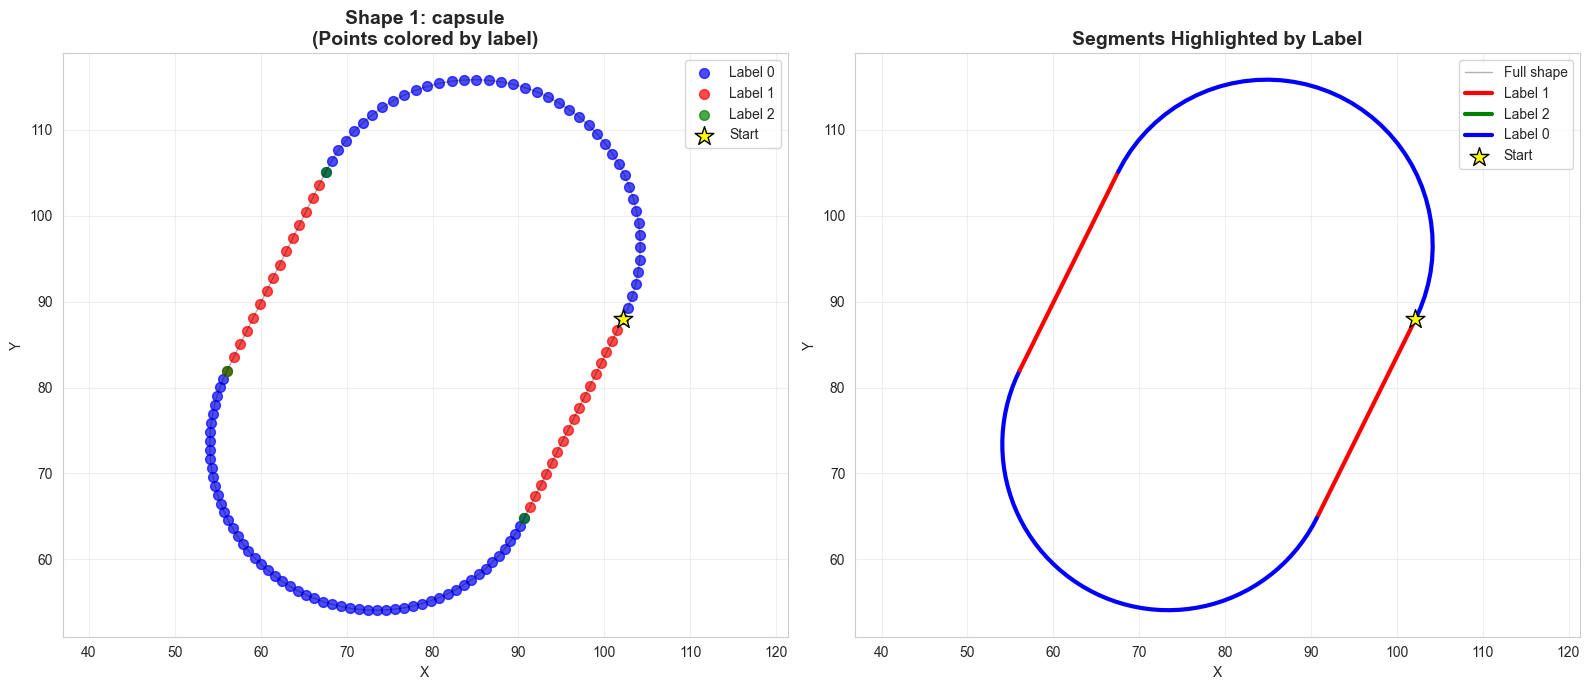


Label statistics within this shape:
  Label 0: 99 points (72.8%)
  Label 1: 33 points (24.3%)
  Label 2: 4 points (2.9%)

Extracting continuous segments...
Found 48310 continuous segments

Segments per label:
  Label 0: 18347 segments
  Label 1: 29963 segments

INVESTIGATING LABEL 2
Total points with label 2: 48310

Label 2 segment lengths: min=1, max=1, mean=1.0
Segments < 5 points: 48310 out of 48310
This explains why no segments shown - they're all filtered by min_segment_length=5!

Re-extracting segments with min_segment_length=1 to show label 2...

Segments per label (unfiltered):
  Label 0: 18347 segments
  Label 1: 29963 segments
  Label 2: 48310 segments

CONTINUOUS SEGMENT SAMPLES BY LABEL

Plotting Label 0...


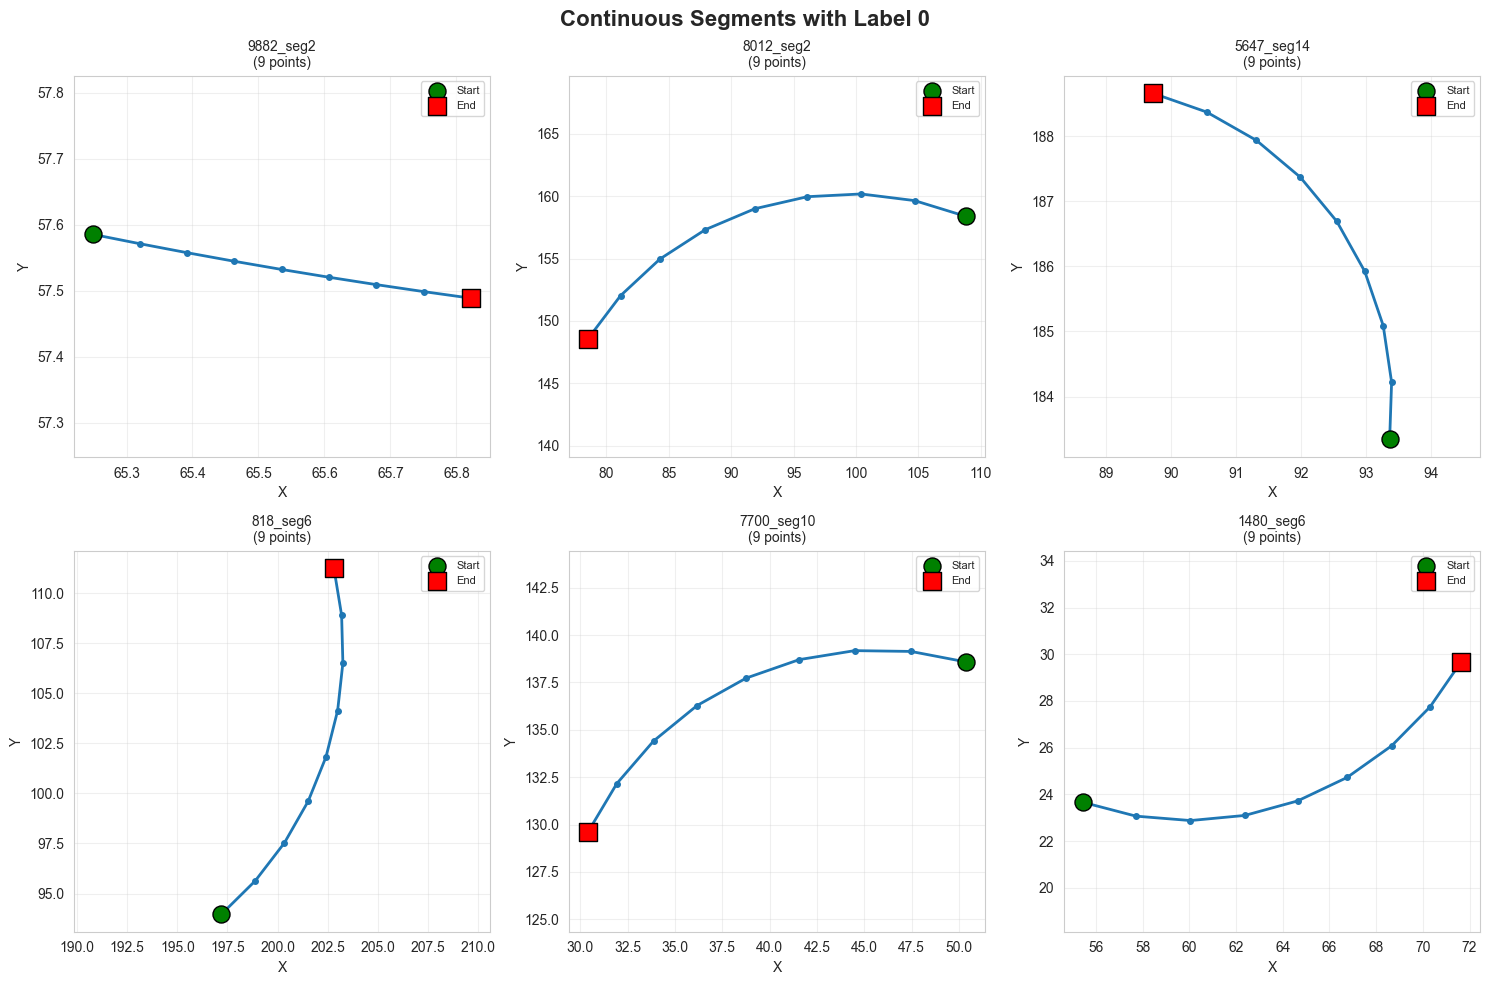


Plotting Label 1...


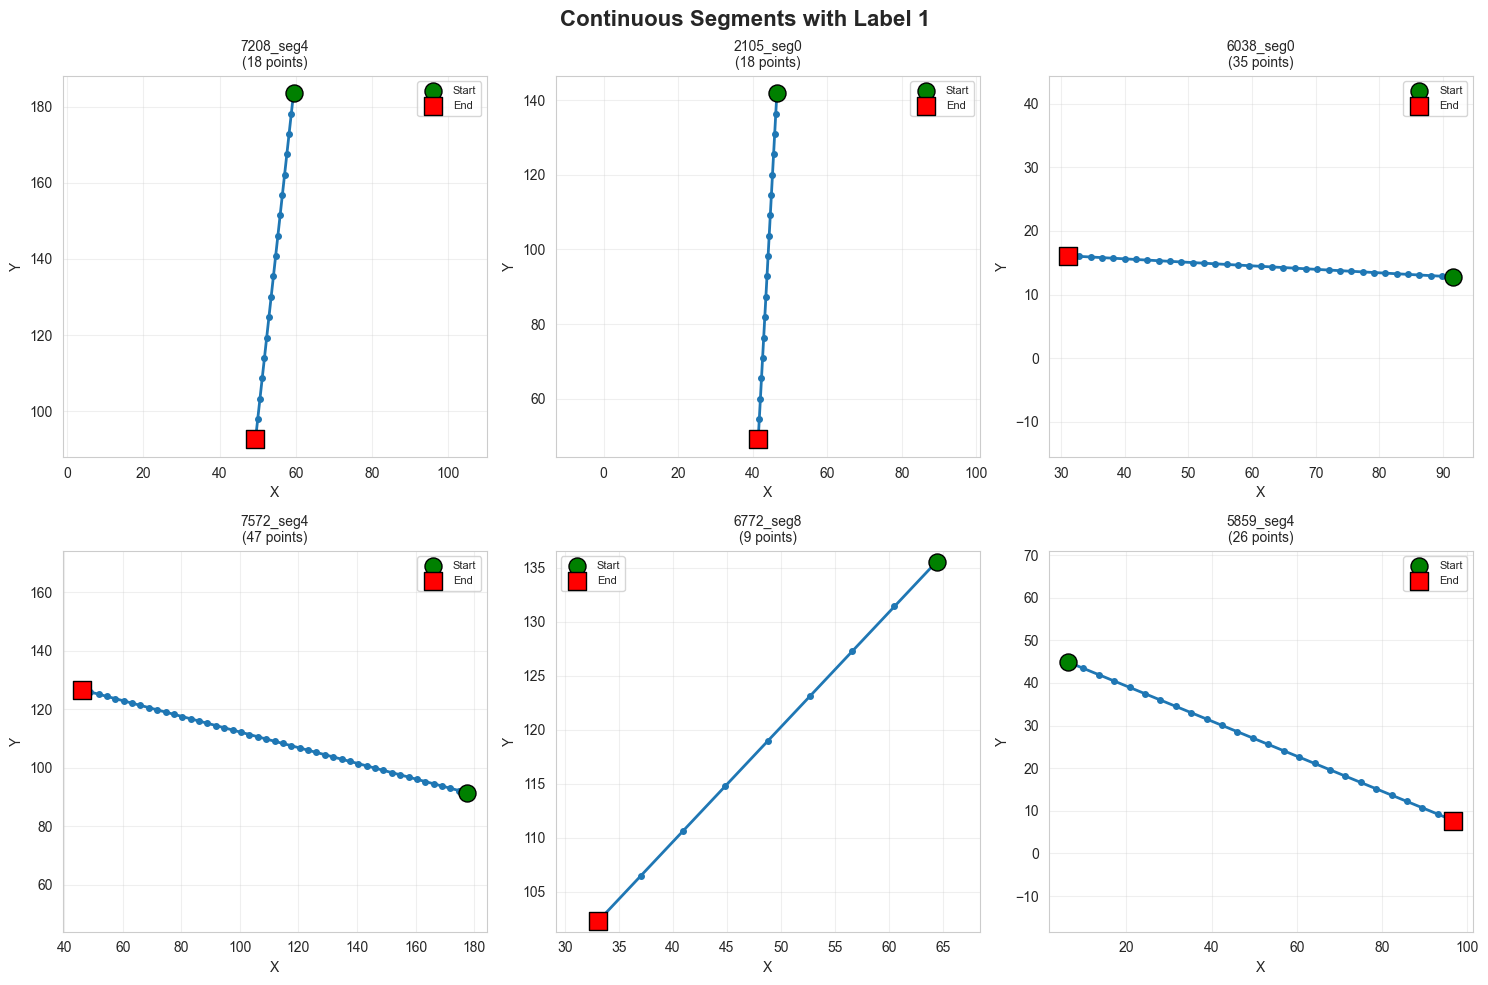


Plotting Label 2...


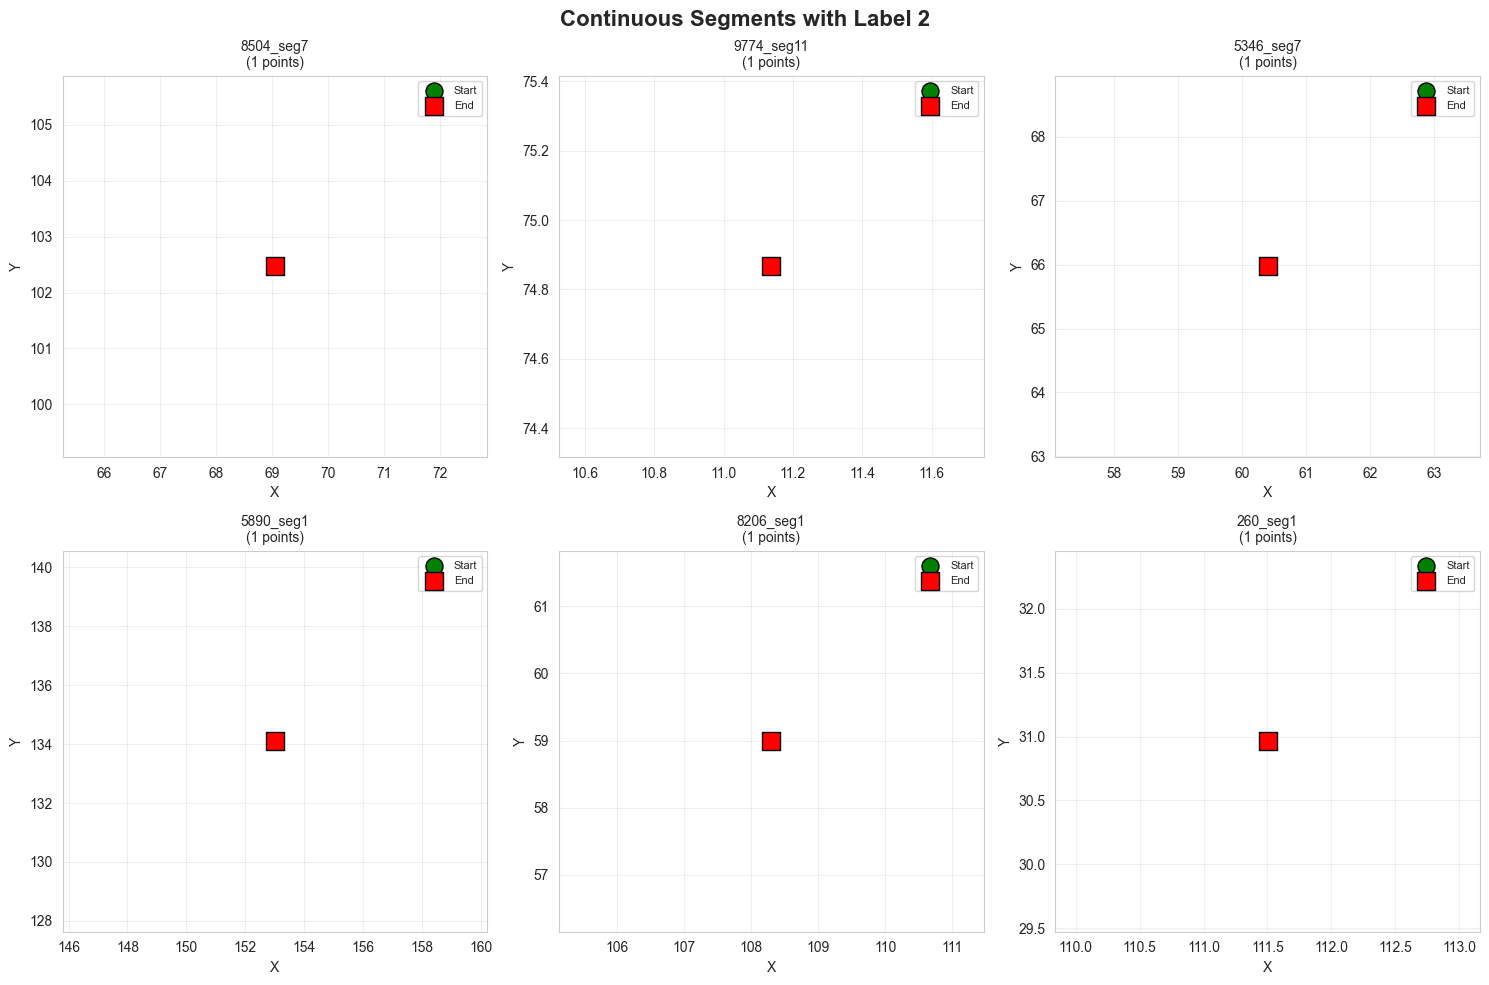


CLASSIFICATION STRATEGY DECISION
Based on the analysis:
  • Label 0 = Arcs (curved segments)
  • Label 1 = Lines (straight segments)
  • Label 2 = Transition points (1-4 points, not useful)

RECOMMENDATION: Binary Classification
  → Class 0: Arcs
  → Class 1: Lines
  → Remove Label 2 (too short for sequence learning)

Dataset after filtering (min_segment_length >= 5):
  • Arc segments (label 0): 18347
  • Line segments (label 1): 29963
  • Total usable segments: 48310
  • Class balance: 38.0% arcs, 62.0% lines


In [9]:
# Pick a shape that has all 3 labels
print("Looking for shapes with multiple labels...")
shape_label_counts = df.groupby('shape_id')['label'].nunique()
multi_label_shapes = shape_label_counts[shape_label_counts > 1].index.tolist()

if multi_label_shapes:
    sample_shape_id = multi_label_shapes[0]
    shape_data = df[df['shape_id'] == sample_shape_id].copy()
    shape_type = shape_data['shape'].iloc[0]
    
    print(f"\nAnalyzing shape_id {sample_shape_id} (type: {shape_type})")
    print(f"This shape contains {len(shape_data)} points with labels:")
    print(shape_data['label'].value_counts().sort_index())
    
    # Visualize with different colors per label
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot 1: All points colored by label
    colors = {0: 'blue', 1: 'red', 2: 'green'}
    label_names = {0: 'Label 0', 1: 'Label 1', 2: 'Label 2'}
    
    for label in sorted(shape_data['label'].unique()):
        label_points = shape_data[shape_data['label'] == label]
        axes[0].scatter(label_points['x'], label_points['y'], 
                       c=colors[label], s=50, alpha=0.7, label=label_names[label])
    
    axes[0].plot(shape_data['x'], shape_data['y'], 'k-', alpha=0.3, linewidth=1)
    axes[0].scatter(shape_data['x'].iloc[0], shape_data['y'].iloc[0], 
                   c='yellow', s=200, marker='*', label='Start', zorder=10, edgecolors='black')
    axes[0].set_title(f'Shape {sample_shape_id}: {shape_type}\n(Points colored by label)', 
                     fontsize=14, fontweight='bold')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].axis('equal')
    
    # Plot 2: Sequential segments
    axes[1].plot(shape_data['x'], shape_data['y'], 'k-', alpha=0.3, linewidth=1, label='Full shape')
    
    # Draw each continuous segment with its label
    current_label = shape_data['label'].iloc[0]
    segment_start = 0
    
    for i in range(1, len(shape_data)):
        if shape_data['label'].iloc[i] != current_label:
            # Draw segment
            segment = shape_data.iloc[segment_start:i+1]
            axes[1].plot(segment['x'], segment['y'], 
                        color=colors[current_label], linewidth=3, 
                        label=f'Label {current_label}' if segment_start == 0 or current_label not in [shape_data['label'].iloc[j] for j in range(segment_start)] else '')
            
            current_label = shape_data['label'].iloc[i]
            segment_start = i
    
    # Draw last segment
    segment = shape_data.iloc[segment_start:]
    axes[1].plot(segment['x'], segment['y'], 
                color=colors[current_label], linewidth=3)
    
    axes[1].scatter(shape_data['x'].iloc[0], shape_data['y'].iloc[0], 
                   c='yellow', s=200, marker='*', label='Start', zorder=10, edgecolors='black')
    axes[1].set_title('Segments Highlighted by Label', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Y')
    handles, labels_legend = axes[1].get_legend_handles_labels()
    by_label = dict(zip(labels_legend, handles))
    axes[1].legend(by_label.values(), by_label.keys())
    axes[1].grid(True, alpha=0.3)
    axes[1].axis('equal')
    
    plt.tight_layout()
    plt.show()
    
    # Show statistics per label within this shape
    print("\nLabel statistics within this shape:")
    for label in sorted(shape_data['label'].unique()):
        label_segment = shape_data[shape_data['label'] == label]
        print(f"  Label {label}: {len(label_segment)} points ({len(label_segment)/len(shape_data)*100:.1f}%)")
else:
    print("All shapes have only one label. Let's visualize by label type instead.")
    
# Extract continuous segments (just like preprocessing.py does)
def extract_continuous_segments(df, min_segment_length=5):
    """
    Extract continuous segments from the dataframe.
    Each segment is a continuous sequence of points with the same label.
    """
    segments = []
    
    for shape_id in df['shape_id'].unique():
        shape_data = df[df['shape_id'] == shape_id].sort_index()
        label_array = shape_data['label'].values
        
        # Find segment boundaries (where label changes)
        segment_starts = [0]
        for i in range(1, len(label_array)):
            if label_array[i] != label_array[i-1]:
                segment_starts.append(i)
        segment_starts.append(len(label_array))
        
        # Extract each continuous segment
        for seg_num, (start, end) in enumerate(zip(segment_starts[:-1], segment_starts[1:])):
            segment_length = end - start
            
            if segment_length >= min_segment_length:
                segment = shape_data.iloc[start:end]
                segments.append({
                    'shape_id': shape_id,
                    'segment_id': f"{shape_id}_seg{seg_num}",
                    'label': segment['label'].iloc[0],
                    'coords': segment[['x', 'y']].values,
                    'n_points': len(segment)
                })
    
    return segments

print("\nExtracting continuous segments...")
all_segments = extract_continuous_segments(df, min_segment_length=5)
print(f"Found {len(all_segments)} continuous segments")

# Count segments by label
segment_counts = {}
for seg in all_segments:
    label = seg['label']
    segment_counts[label] = segment_counts.get(label, 0) + 1

print("\nSegments per label:")
for label in sorted(segment_counts.keys()):
    print(f"  Label {label}: {segment_counts[label]} segments")

# Plot sample segments
def plot_continuous_segments(segments, target_label, n_samples=6, title=""):
    """Plot continuous segment samples for a given label."""
    label_segments = [s for s in segments if s['label'] == target_label]
    
    if len(label_segments) == 0:
        print(f"No segments found for label {target_label}")
        return
    
    sample_segments = np.random.choice(label_segments, min(n_samples, len(label_segments)), replace=False)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, segment in enumerate(sample_segments):
        coords = segment['coords']
        x, y = coords[:, 0], coords[:, 1]
        
        axes[idx].plot(x, y, 'o-', markersize=4, linewidth=2)
        axes[idx].scatter(x[0], y[0], c='green', s=150, marker='o', label='Start', zorder=5, edgecolors='black')
        axes[idx].scatter(x[-1], y[-1], c='red', s=150, marker='s', label='End', zorder=5, edgecolors='black')
        axes[idx].set_title(f"{segment['segment_id']}\n({segment['n_points']} points)", fontsize=10)
        axes[idx].set_xlabel('X')
        axes[idx].set_ylabel('Y')
        axes[idx].legend(fontsize=8)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].axis('equal')
    
    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Investigate Label 2 - why no segments?
print("\n" + "="*80)
print("INVESTIGATING LABEL 2")
print("="*80)
print(f"Total points with label 2: {len(df[df['label']==2])}")

# Check segment lengths for label 2
label_2_segment_lengths = []
for shape_id in df['shape_id'].unique():
    shape_data = df[df['shape_id'] == shape_id].sort_index()
    label_array = shape_data['label'].values
    
    segment_starts = [0]
    for i in range(1, len(label_array)):
        if label_array[i] != label_array[i-1]:
            segment_starts.append(i)
    segment_starts.append(len(label_array))
    
    for start, end in zip(segment_starts[:-1], segment_starts[1:]):
        segment_label = label_array[start]
        segment_length = end - start
        if segment_label == 2:
            label_2_segment_lengths.append(segment_length)

if label_2_segment_lengths:
    print(f"\nLabel 2 segment lengths: min={min(label_2_segment_lengths)}, max={max(label_2_segment_lengths)}, mean={np.mean(label_2_segment_lengths):.1f}")
    print(f"Segments < 5 points: {sum(1 for x in label_2_segment_lengths if x < 5)} out of {len(label_2_segment_lengths)}")
    print(f"This explains why no segments shown - they're all filtered by min_segment_length=5!")
else:
    print("No label 2 segments found at all!")

# Re-extract with min_segment_length=1 to see label 2
print("\nRe-extracting segments with min_segment_length=1 to show label 2...")
all_segments_unfiltered = extract_continuous_segments(df, min_segment_length=1)

segment_counts_unfiltered = {}
for seg in all_segments_unfiltered:
    label = seg['label']
    segment_counts_unfiltered[label] = segment_counts_unfiltered.get(label, 0) + 1

print("\nSegments per label (unfiltered):")
for label in sorted(segment_counts_unfiltered.keys()):
    print(f"  Label {label}: {segment_counts_unfiltered[label]} segments")

print("\n" + "="*80)
print("CONTINUOUS SEGMENT SAMPLES BY LABEL")
print("="*80)
for label in sorted(df['label'].unique()):
    print(f"\nPlotting Label {label}...")
    plot_continuous_segments(all_segments_unfiltered, label, title=f"Continuous Segments with Label {label}")

print("\n" + "="*80)
print("CLASSIFICATION STRATEGY DECISION")
print("="*80)
print("Based on the analysis:")
print("  • Label 0 = Arcs (curved segments)")
print("  • Label 1 = Lines (straight segments)")
print("  • Label 2 = Transition points (1-4 points, not useful)")
print("\nRECOMMENDATION: Binary Classification")
print("  → Class 0: Arcs")
print("  → Class 1: Lines")
print("  → Remove Label 2 (too short for sequence learning)")
print("\nDataset after filtering (min_segment_length >= 5):")
binary_segments = [s for s in all_segments if s['label'] in [0, 1]]
binary_counts = {0: 0, 1: 0}
for seg in binary_segments:
    binary_counts[seg['label']] += 1
print(f"  • Arc segments (label 0): {binary_counts[0]}")
print(f"  • Line segments (label 1): {binary_counts[1]}")
print(f"  • Total usable segments: {len(binary_segments)}")
print(f"  • Class balance: {binary_counts[0]/(binary_counts[0]+binary_counts[1])*100:.1f}% arcs, {binary_counts[1]/(binary_counts[0]+binary_counts[1])*100:.1f}% lines")
print("="*80)


## 3. Coordinate Normalization Demo

**⚠️ IMPORTANT: Why Normalize?**

Normalize coordinates to achieve:
- **Translation Invariance**: Shape at (0,0) = shape at (100,100)
- **Scale Invariance**: Small arc = large arc (same geometry)
- **Focus on Geometry**: Features capture shape, not size/position


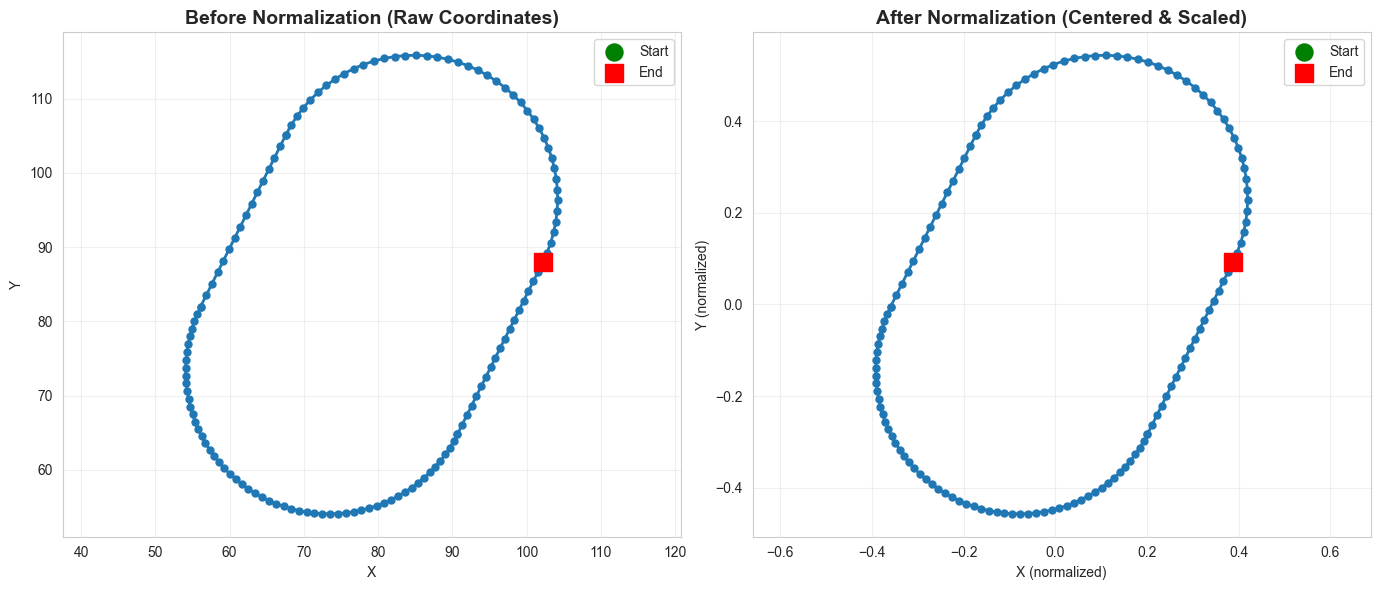

Original range: X=[54.07, 104.18], Y=[54.07, 115.85]
Normalized range: X=[-0.39, 0.42], Y=[-0.46, 0.54]


In [10]:
# Demonstrate normalization with examples
sample_shape_id = df['shape_id'].unique()[0]
sample_data = df[df['shape_id'] == sample_shape_id]
sample_coords = sample_data[['x', 'y']].values

# Show before/after
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before normalization
axes[0].plot(sample_coords[:, 0], sample_coords[:, 1], 'o-', linewidth=2, markersize=5)
axes[0].scatter(sample_coords[0, 0], sample_coords[0, 1], c='green', s=150, marker='o', label='Start', zorder=5)
axes[0].scatter(sample_coords[-1, 0], sample_coords[-1, 1], c='red', s=150, marker='s', label='End', zorder=5)
axes[0].set_title('Before Normalization (Raw Coordinates)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].axis('equal')

# After normalization
def normalize_coordinates(coords):
    centroid = coords.mean(axis=0)
    coords_centered = coords - centroid
    max_range = max(coords_centered[:, 0].max() - coords_centered[:, 0].min(),
                    coords_centered[:, 1].max() - coords_centered[:, 1].min())
    if max_range > 1e-8:
        coords_normalized = coords_centered / max_range
    else:
        coords_normalized = coords_centered
    return coords_normalized

normalized_coords = normalize_coordinates(sample_coords)
axes[1].plot(normalized_coords[:, 0], normalized_coords[:, 1], 'o-', linewidth=2, markersize=5)
axes[1].scatter(normalized_coords[0, 0], normalized_coords[0, 1], c='green', s=150, marker='o', label='Start', zorder=5)
axes[1].scatter(normalized_coords[-1, 0], normalized_coords[-1, 1], c='red', s=150, marker='s', label='End', zorder=5)
axes[1].set_title('After Normalization (Centered & Scaled)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('X (normalized)')
axes[1].set_ylabel('Y (normalized)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].axis('equal')

plt.tight_layout()
plt.show()

print(f"Original range: X=[{sample_coords[:, 0].min():.2f}, {sample_coords[:, 0].max():.2f}], "
      f"Y=[{sample_coords[:, 1].min():.2f}, {sample_coords[:, 1].max():.2f}]")
print(f"Normalized range: X=[{normalized_coords[:, 0].min():.2f}, {normalized_coords[:, 0].max():.2f}], "
      f"Y=[{normalized_coords[:, 1].min():.2f}, {normalized_coords[:, 1].max():.2f}]")


## 4. Feature Engineering Functions

def normalize_coordinates(coords):
    """
    Normalize coordinates to be scale and translation invariant.
    
    Args:
        coords: Nx2 array of (x, y) coordinates
    
    Returns:
        Normalized coordinates centered at origin and scaled to unit size
    """
    # Center at origin (translation invariance)
    centroid = coords.mean(axis=0)
    coords_centered = coords - centroid
    
    # Scale to unit size (scale invariance)
    # Use max range to preserve aspect ratio
    max_range = max(coords_centered[:, 0].max() - coords_centered[:, 0].min(),
                    coords_centered[:, 1].max() - coords_centered[:, 1].min())
    
    if max_range > 1e-8:  # Avoid division by zero
        coords_normalized = coords_centered / max_range
    else:
        coords_normalized = coords_centered
    
    return coords_normalized


def compute_trajectory_features(coords, normalize=True):
    """
    Compute comprehensive features for a trajectory.
    
    Args:
        coords: Nx2 array of (x, y) coordinates
        normalize: Whether to normalize coordinates first (recommended)
    
    Returns:
        Dictionary of features
    """
    # Store original stats before normalization
    original_x, original_y = coords[:, 0], coords[:, 1]
    features = {}
    features['original_x_range'] = original_x.max() - original_x.min()
    features['original_y_range'] = original_y.max() - original_y.min()
    
    # Normalize coordinates for scale/translation invariance
    if normalize:
        coords = normalize_coordinates(coords)
    
    x, y = coords[:, 0], coords[:, 1]
    n_points = len(x)
    
    # Basic statistics
    features['n_points'] = n_points
    features['x_range'] = x.max() - x.min()
    features['y_range'] = y.max() - y.min()
    
    # Centroid and spread (now relative after normalization)
    centroid_x, centroid_y = x.mean(), y.mean()
    
    # Distance from centroid (key for arc detection)
    dist_from_centroid = np.sqrt((x - centroid_x)**2 + (y - centroid_y)**2)
    features['mean_dist_from_centroid'] = dist_from_centroid.mean()
    features['std_dist_from_centroid'] = dist_from_centroid.std()
    features['cv_dist_from_centroid'] = dist_from_centroid.std() / (dist_from_centroid.mean() + 1e-8)
    
    # First order differences (velocity)
    dx = np.diff(x)
    dy = np.diff(y)
    
    # Step distances
    step_distances = np.sqrt(dx**2 + dy**2)
    features['mean_step_distance'] = step_distances.mean()
    features['std_step_distance'] = step_distances.std()
    features['total_path_length'] = step_distances.sum()
    
    # Straight line distance (start to end)
    straight_line_dist = np.sqrt((x[-1] - x[0])**2 + (y[-1] - y[0])**2)
    features['straight_line_distance'] = straight_line_dist
    features['tortuosity'] = features['total_path_length'] / (straight_line_dist + 1e-8)
    
    # Direction angles
    angles = np.arctan2(dy, dx)
    features['mean_angle'] = np.mean(angles)
    features['std_angle'] = np.std(angles)
    
    # Curvature (change in angle) - KEY FEATURE
    curvature = np.diff(angles)
    curvature = np.arctan2(np.sin(curvature), np.cos(curvature))
    features['mean_abs_curvature'] = np.abs(curvature).mean()
    features['std_curvature'] = curvature.std()
    features['max_abs_curvature'] = np.abs(curvature).max()
    features['total_angle_change'] = np.abs(curvature).sum()
    
    # Line fit
    if n_points > 2:
        A = np.vstack([x, np.ones(len(x))]).T
        a, b = np.linalg.lstsq(A, y, rcond=None)[0]
        y_fit = a * x + b
        residuals = y - y_fit
        features['line_fit_residual_mean'] = np.abs(residuals).mean()
        features['line_fit_r_squared'] = 1 - (np.sum(residuals**2) / (np.sum((y - y.mean())**2) + 1e-8))
    
    # Circle fit (for arcs)
    if n_points > 3:
        circle_center_x = (x.max() + x.min()) / 2
        circle_center_y = (y.max() + y.min()) / 2
        radii = np.sqrt((x - circle_center_x)**2 + (y - circle_center_y)**2)
        features['mean_radius'] = radii.mean()
        features['std_radius'] = radii.std()
        features['cv_radius'] = radii.std() / (radii.mean() + 1e-8)
    
    # Acceleration
    if len(dx) > 1:
        ddx = np.diff(dx)
        ddy = np.diff(dy)
        acceleration = np.sqrt(ddx**2 + ddy**2)
        features['mean_acceleration'] = acceleration.mean()
    
    return features


In [11]:
# Extract features for each shape
feature_list = []

print("Extracting features from trajectories...")
for shape_id in df['shape_id'].unique():
    shape_data = df[df['shape_id'] == shape_id]
    coords = shape_data[['x', 'y']].values
    label = shape_data['label'].iloc[0]
    shape_type = shape_data['shape'].iloc[0]
    
    # Compute features
    features = compute_trajectory_features(coords)
    features['shape_id'] = shape_id
    features['label'] = label
    features['shape_type'] = shape_type
    
    feature_list.append(features)

# Create feature dataframe
feature_df = pd.DataFrame(feature_list)
print(f"\nExtracted {len(feature_df)} trajectories with {len(feature_df.columns)-3} features")
print(f"\nFeature DataFrame shape: {feature_df.shape}")
feature_df.head()


Extracting features from trajectories...

Extracted 10000 trajectories with 25 features

Feature DataFrame shape: (10000, 28)


,original_x_range,original_y_range,n_points,x_range,y_range,mean_dist_from_centroid,std_dist_from_centroid,cv_dist_from_centroid,mean_step_distance,std_step_distance,...,total_angle_change,line_fit_residual_mean,line_fit_r_squared,mean_radius,std_radius,cv_radius,mean_acceleration,shape_id,label,shape_type
0,50.114224,61.778966,136,0.811186,1.000000,0.432707,0.075698,0.174941,0.020747,0.004840,...,14.674642,0.287586,0.085292,0.435902,0.070922,0.162703,0.001953,1,1,capsule
1,91.861434,50.731875,73,1.000000,0.552265,0.371788,0.148348,0.399014,0.033383,0.028516,...,17.619602,0.139502,0.361975,0.377864,0.141670,0.374922,0.005037,2,1,triangle_rounded
2,89.439270,89.439553,156,0.999997,1.000000,0.499931,0.005734,0.011469,0.020268,0.001717,...,8.138651,0.317756,0.000149,0.500031,0.000025,0.000049,0.001087,3,0,circle
3,68.722351,85.417337,116,0.804548,1.000000,0.391711,0.113171,0.288914,0.024018,0.011419,...,10.566738,0.204786,0.360132,0.404953,0.100158,0.247332,0.001588,4,1,parallelogram_simple
4,48.660090,61.056549,147,0.796968,1.000000,0.404084,0.099063,0.245154,0.018821,0.002803,...,6.810821,0.260616,0.190693,0.412123,0.112038,0.271856,0.000644,5,0,semicircle


## 5. Feature Analysis: Which Features Best Discriminate?

Let's find which features show the most difference between classes


In [12]:
# Separate numeric features
numeric_cols = feature_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('shape_id')
numeric_cols.remove('label')

print(f"Analyzing {len(numeric_cols)} numeric features...")

# For each label, compute feature statistics
print("\nFeature statistics by label:\n")
for label in sorted(feature_df['label'].unique()):
    label_data = feature_df[feature_df['label'] == label]
    shape_type = label_data['shape_type'].iloc[0]
    print(f"="*60)
    print(f"Label {label}: {shape_type} (n={len(label_data)})")
    print(f"="*60)
    
    # Show key discriminative features
    key_features = ['mean_abs_curvature', 'cv_radius', 'tortuosity', 'line_fit_r_squared', 
                   'cv_dist_from_centroid', 'total_angle_change']
    for feat in key_features:
        if feat in numeric_cols:
            print(f"  {feat:30s}: {label_data[feat].mean():10.4f} ± {label_data[feat].std():10.4f}")
    print()


Analyzing 25 numeric features...

Feature statistics by label:

Label 0: circle (n=1821)
  mean_abs_curvature            :     0.0589 ±     0.0373
  cv_radius                     :     0.1377 ±     0.1304
  tortuosity                    : 239810792.6265 ± 110052393.4224
  line_fit_r_squared            :     0.2471 ±     0.3521
  cv_dist_from_centroid         :     0.1698 ±     0.1128
  total_angle_change            :     6.3149 ±     3.6864

Label 1: capsule (n=8179)
  mean_abs_curvature            :     0.1699 ±     0.1228
  cv_radius                     :     0.2050 ±     0.0940
  tortuosity                    : 285659483.2815 ± 30509889.1714
  line_fit_r_squared            :     0.1344 ±     0.1971
  cv_dist_from_centroid         :     0.2175 ±     0.0913
  total_angle_change            :    16.7615 ±     8.5972



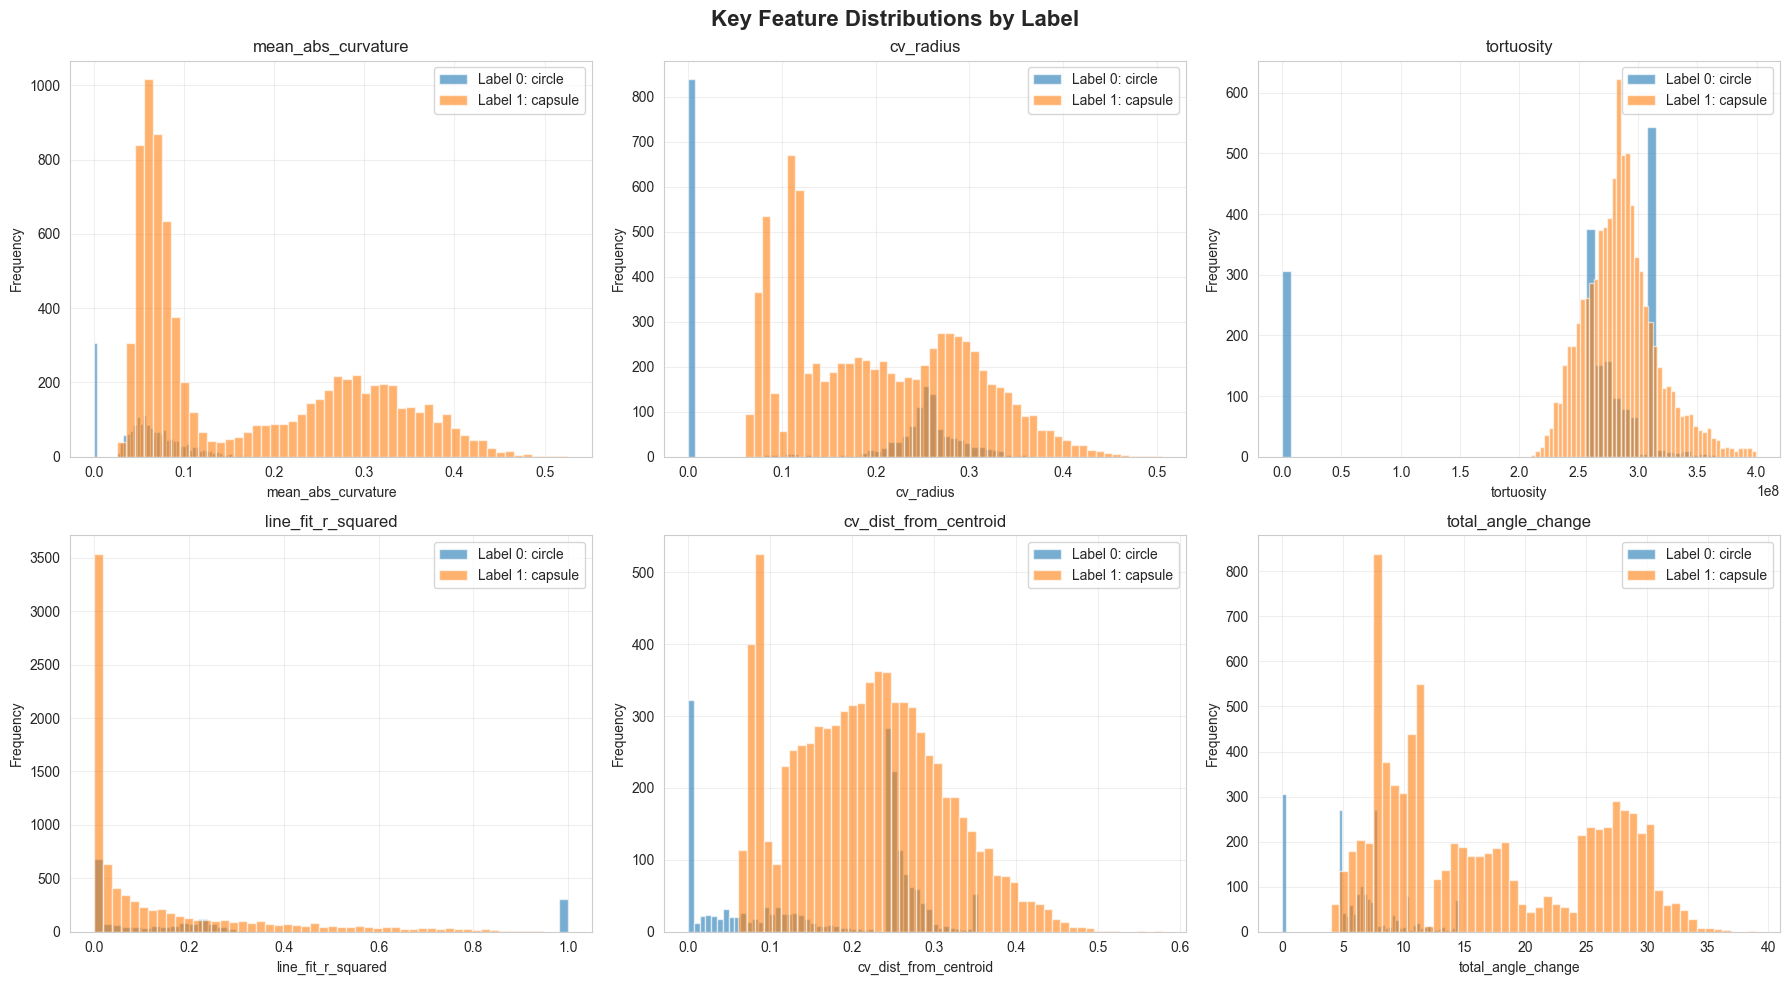

In [13]:
# Visualize key features by label
key_features = ['mean_abs_curvature', 'cv_radius', 'tortuosity', 'line_fit_r_squared', 
               'cv_dist_from_centroid', 'total_angle_change']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feat in enumerate(key_features):
    if feat in feature_df.columns:
        for label in sorted(feature_df['label'].unique()):
            data = feature_df[feature_df['label'] == label][feat]
            shape_type = feature_df[feature_df['label'] == label]['shape_type'].iloc[0]
            axes[idx].hist(data, alpha=0.6, bins=50, label=f"Label {label}: {shape_type}")
        
        axes[idx].set_xlabel(feat)
        axes[idx].set_ylabel('Frequency')
        axes[idx].set_title(f'{feat}')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

plt.suptitle('Key Feature Distributions by Label', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Feature Importance Analysis


Training Random Forest to assess feature importance...

Top 15 Important Features:
                    feature  importance
16            std_curvature    0.216354
23                cv_radius    0.173726
18       total_angle_change    0.161877
22               std_radius    0.105053
17        max_abs_curvature    0.055660
7     cv_dist_from_centroid    0.053395
6    std_dist_from_centroid    0.027185
9         std_step_distance    0.025738
10        total_path_length    0.020897
2                  n_points    0.019034
15       mean_abs_curvature    0.019016
11   straight_line_distance    0.017596
5   mean_dist_from_centroid    0.017563
20       line_fit_r_squared    0.015960
12               tortuosity    0.013040


<Figure size 1000x1000 with 0 Axes>

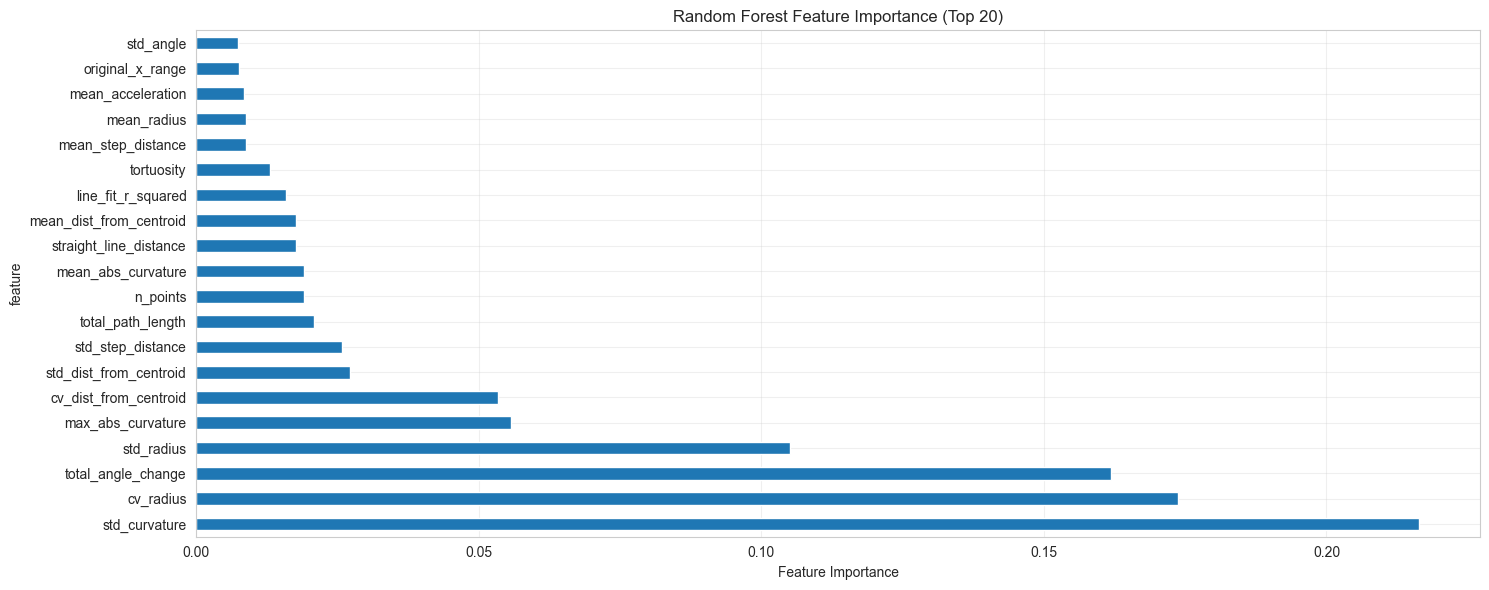


Random Forest Accuracy: 0.9996


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Prepare data
X = feature_df[numeric_cols].fillna(0).replace([np.inf, -np.inf], 0)
y = feature_df['label']

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train simple RF to get feature importances
print("Training Random Forest to assess feature importance...")
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_scaled, y)

# Get feature importances
importances = pd.DataFrame({
    'feature': numeric_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Important Features:")
print(importances.head(15))

# Plot
plt.figure(figsize=(10, 10))
importances.head(20).plot(x='feature', y='importance', kind='barh', legend=False)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance (Top 20)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nRandom Forest Accuracy: {rf.score(X_scaled, y):.4f}")


## 7. Save Enhanced Feature Dataset


In [15]:
# Select top features based on importance
n_top_features = 20
selected_features = importances.head(n_top_features)['feature'].tolist()

print(f"Selected top {n_top_features} features:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feat}")

# Create enhanced dataset
enhanced_df = feature_df[['shape_id', 'label', 'shape_type'] + selected_features].copy()

# Handle missing/inf values
enhanced_df[selected_features] = enhanced_df[selected_features].fillna(0).replace([np.inf, -np.inf], 0)

print(f"\nEnhanced dataset shape: {enhanced_df.shape}")
enhanced_df.head()


Selected top 20 features:
   1. std_curvature
   2. cv_radius
   3. total_angle_change
   4. std_radius
   5. max_abs_curvature
   6. cv_dist_from_centroid
   7. std_dist_from_centroid
   8. std_step_distance
   9. total_path_length
  10. n_points
  11. mean_abs_curvature
  12. straight_line_distance
  13. mean_dist_from_centroid
  14. line_fit_r_squared
  15. tortuosity
  16. mean_step_distance
  17. mean_radius
  18. mean_acceleration
  19. original_x_range
  20. std_angle

Enhanced dataset shape: (10000, 23)


,shape_id,label,shape_type,std_curvature,cv_radius,total_angle_change,std_radius,max_abs_curvature,cv_dist_from_centroid,std_dist_from_centroid,...,mean_abs_curvature,straight_line_distance,mean_dist_from_centroid,line_fit_r_squared,tortuosity,mean_step_distance,mean_radius,mean_acceleration,original_x_range,std_angle
0,1,1,capsule,0.316048,0.162703,14.674642,0.070922,2.058915,0.174941,0.075698,...,0.109512,2.359224e-16,0.432707,0.085292,2.800805e+08,0.020747,0.435902,0.001953,50.114224,1.828133
1,2,1,triangle_rounded,0.669791,0.374922,17.619602,0.141670,2.756779,0.399014,0.148348,...,0.248163,0.000000e+00,0.371788,0.361975,2.403583e+08,0.033383,0.377864,0.005037,91.861434,1.695216
2,3,0,circle,0.110407,0.000049,8.138651,0.000025,0.988974,0.011469,0.005734,...,0.052848,0.000000e+00,0.499931,0.000149,3.141569e+08,0.020268,0.500031,0.001087,89.439270,1.822670
3,4,1,parallelogram_simple,0.431598,0.247332,10.566738,0.100158,2.533906,0.288914,0.113171,...,0.092691,0.000000e+00,0.391711,0.360132,2.762036e+08,0.024018,0.404953,0.001588,68.722351,1.481288
4,5,0,semicircle,0.235750,0.271856,6.810821,0.112038,2.644303,0.245154,0.099063,...,0.046971,0.000000e+00,0.404084,0.190693,2.747931e+08,0.018821,0.412123,0.000644,48.660090,1.824365


In [16]:
# Save enhanced feature dataset
output_path = '../../data/enhanced_features.csv'
enhanced_df.to_csv(output_path, index=False)
print(f"Enhanced feature dataset saved to: {output_path}")
print(f"Shape: {enhanced_df.shape}")
print(f"\nColumns: {enhanced_df.columns.tolist()}")


Enhanced feature dataset saved to: ../../data/enhanced_features.csv
Shape: (10000, 23)

Columns: ['shape_id', 'label', 'shape_type', 'std_curvature', 'cv_radius', 'total_angle_change', 'std_radius', 'max_abs_curvature', 'cv_dist_from_centroid', 'std_dist_from_centroid', 'std_step_distance', 'total_path_length', 'n_points', 'mean_abs_curvature', 'straight_line_distance', 'mean_dist_from_centroid', 'line_fit_r_squared', 'tortuosity', 'mean_step_distance', 'mean_radius', 'mean_acceleration', 'original_x_range', 'std_angle']
